# Price Analysis - Casas de California

Notebook sobre el analisis realizado al dataset de `data/housing.csv` (20.640 distritos de California, de Kaggle).

Estructura:
1. Importacion de librerías
2. Carga de datos
3. Exploración inicial
4. Limpieza / preprocesamiento
5. Análisis simple
6. Análisis complejo

# Sección 1 - Importacion de librerías

pandas (tablas), numpy (matemática), matplotlib y seaborn (gráficos).
`sns.set_theme()` aplica estilo y `%matplotlib inline` muestra los gráficos dentro del notebook.

In [1]:
import pandas as pd       
import numpy as np        
import matplotlib.pyplot as plt  #  gráficos
import seaborn as sns     # (estilos avanzados)

sns.set_theme()           

%matplotlib inline        

# Sección 2 - Carga de datos

El notebook está en `notebooks/`, por eso la ruta sube un nivel: `../data/housing.csv`.

In [2]:
df = pd.read_csv("../data/housing.csv") 

df.shape  # dimension del dataset (filas, columnas)

(20640, 10)

# Sección 3 - Exploración inicial

Qué se revisó:
- Primeras filas con `.head()`.
- Dimensiones: 20.640 filas y 10 columnas.
- Tipos de datos: 9 columnas numéricas (float64) y `ocean_proximity` como texto.
- Nulos: solo `total_bedrooms` tiene 207.
- Resumen estadístico con `.describe()`.
- Duplicados: no hay.

In [3]:
estructure = df.head()              
dimension = df.shape                     
columns = df.columns                 
types = df.dtypes                    
nulls = df.isnull().sum()            
resume = df.describe()               # estadísticas resumidas: count, mean, std, min, max, cuartiles
duplicates = df.duplicated().sum()   

display(estructure, dimension, columns, types, nulls, resume, duplicates)  # muestra todo en el notebook

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


(20640, 10)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


np.int64(0)

# Sección 4 - Limpieza / preprocesamiento

 Decisión: nulos de `total_bedrooms`

Se hallaron un total de 207 nulos (~1%) en la columna de 'total_bedrooms', para preservar esas entradas del dataset se relleno tales faltas con la mediana, en lugar de borrar las filas.

Luego se verificó que no quedaran nulos y se revisaron las categorías de
`ocean_proximity`.

In [4]:


median = df['total_bedrooms'].median()  

df['total_bedrooms'] = df['total_bedrooms'].fillna(median)  

display(df.isnull().sum())  

df['ocean_proximity'].value_counts()  

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

# Sección 4b - Feature Engineering 

Creamos ratios que se usan en la industria inmobiliaria. Estos ratios
correlacionan mejor con el precio que las variables crudas.

In [5]:
# rooms_per_house: tamaño promedio de los hogares
df['rooms_per_house'] = df['total_rooms'] / df['households']

# people_per_house: indica densidad de ocupación
df['people_per_house'] = df['population'] / df['households']

# bedrooms_ratio: indica diseño de la vivienda
df['bedrooms_ratio'] = df['total_bedrooms'] / df['total_rooms']

# Verificacion de nuevas columnas
df[['rooms_per_house', 'people_per_house', 'bedrooms_ratio']].describe()

,rooms_per_house,people_per_house,bedrooms_ratio
count,20640.000000,20640.000000,20640.000000
mean,5.429000,3.070655,0.213794
std,2.474173,10.386050,0.065248
min,0.846154,0.692308,0.037151
25%,4.440716,2.429741,0.175225
50%,5.229129,2.818116,0.203159
75%,6.052381,3.282261,0.240126
max,141.909091,1243.333333,2.824675


**Hallazgo:** los ratios permiten ver patrones que las variables crudas ocultan:
- `rooms_per_house` promedio ~5.4 (casas típicas de 5-6 ambientes)
- `people_per_house` promedio ~2.9 (familias de 2-3 personas)
- `bedrooms_ratio` promedio ~0.21 (~21% de las habitaciones son dormitorios)

# Sección 5 - Análisis simple

Distribuciones, relación entre variables y segmentación por `ocean_proximity`
y por precio. Cada gráfico está en su propia celda con su hallazgo debajo.

### 1. Histogramas

Text(0.5, 1.0, 'Distribución de median_house_value')

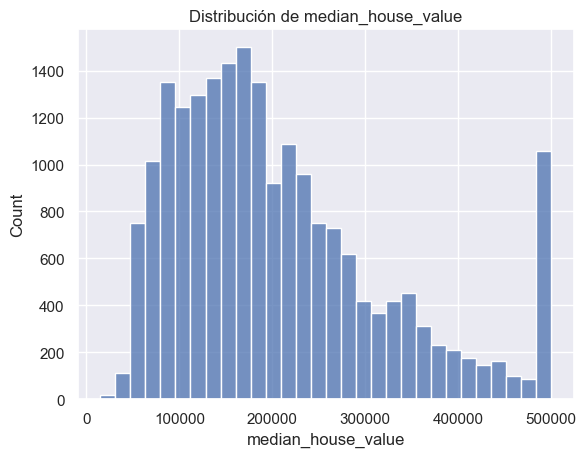

In [6]:
sns.histplot(df['median_house_value'], bins=30)  
plt.title('Distribución de median_house_value')   

**Hallazgo:** la mayoría de las casas valen entre ~$100k y ~$250k. El pico en $500k es porque el precio está capaneado en 500.001.

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>],
       [<Axes: title={'center': 'rooms_per_house'}>,
        <Axes: title={'center': 'people_per_house'}>,
        <Axes: title={'center': 'bedrooms_ratio'}>]], dtype=object)

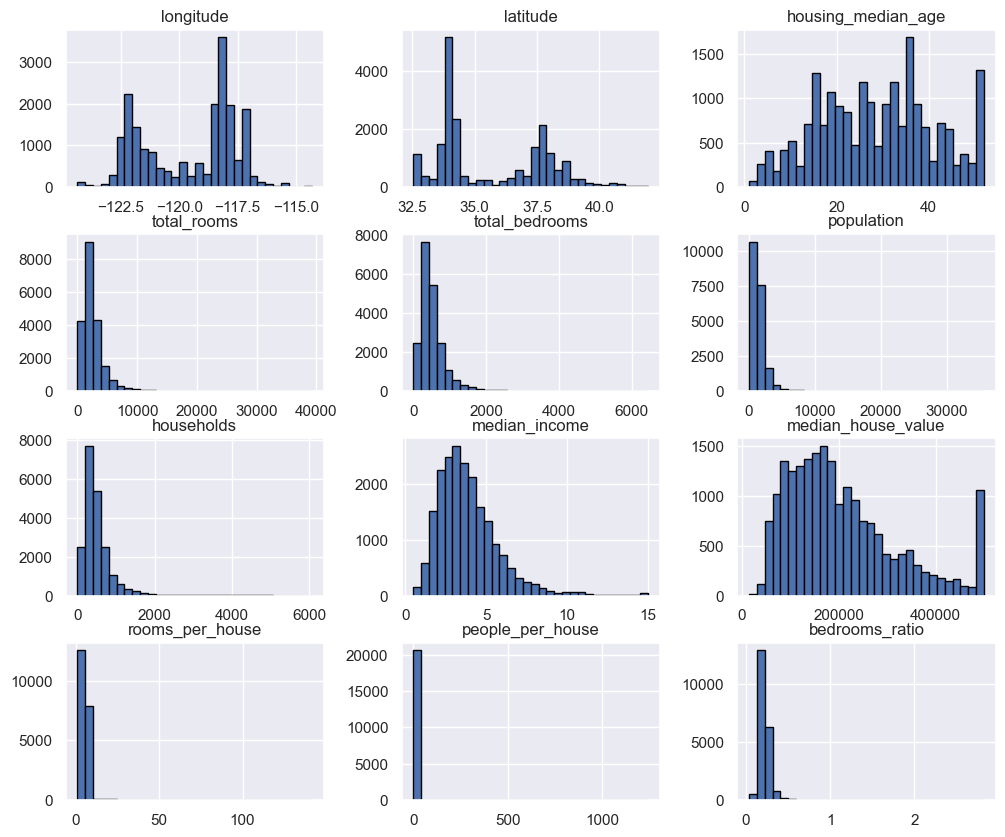

In [7]:
df.hist(figsize=(12, 10), bins=30, edgecolor='black')  # histogramas de todas las columnas numéricas, 12x10 pulgadas, 30 barras, borde negro

**Hallazgo:** la mayoría de las variables están sesgadas a la derecha (pocos distritos con valores muy altos). El objetivo también: la mayoría de los distritos tienen precios medios, pocos muy caros.

### 2. Boxplot: precio según `ocean_proximity`

Text(0.5, 1.0, 'Precio según proximidad al océano')

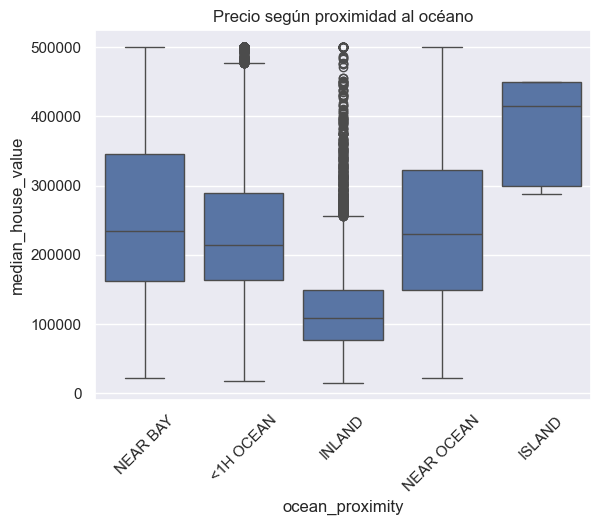

In [8]:
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df) 
plt.xticks(rotation=45) 
plt.title('Precio según proximidad al océano')

**Hallazgo:** las casas `INLAND` (tierra adentro) son las más baratas; `NEAR OCEAN` y `NEAR BAY` las más caras. `ISLAND` tiene solo 5 casos, no es concluyente.

### 3. Scatter: ingreso vs precio

Text(0.5, 1.0, 'Median Income vs. Median House Value')

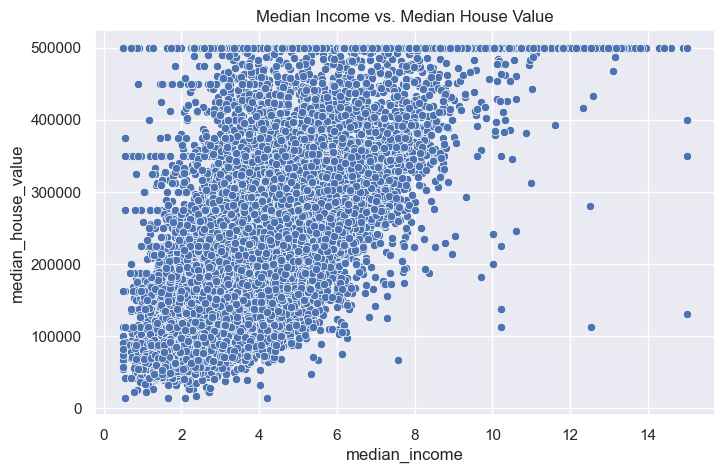

In [9]:
plt.figure(figsize=(8, 5))  
sns.scatterplot(x='median_income', y='median_house_value', data=df)  
plt.title('Median Income vs. Median House Value')  

**Hallazgo:** relación positiva clara: a mayor ingreso medio, mayor precio.

### 4. Scatter: edad vs precio

Text(0.5, 1.0, 'Housing Median Age vs. Median House Value')

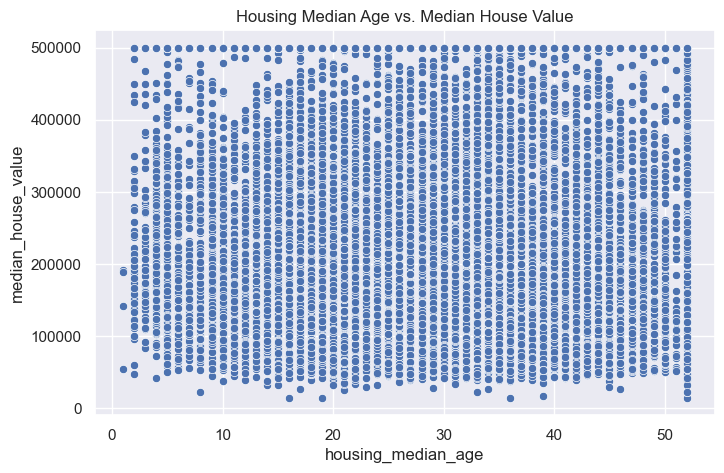

In [10]:
plt.figure(figsize=(8, 5))  
sns.scatterplot(x='housing_median_age', y='median_house_value', data=df) 
plt.title('Housing Median Age vs. Median House Value')  

**Hallazgo:** no hay relación clara entre la edad y el precio (los puntos están repartidos de forma pareja).

### 5. Scatter: ingreso vs población

Text(0.5, 1.0, 'Median Income vs. Population')

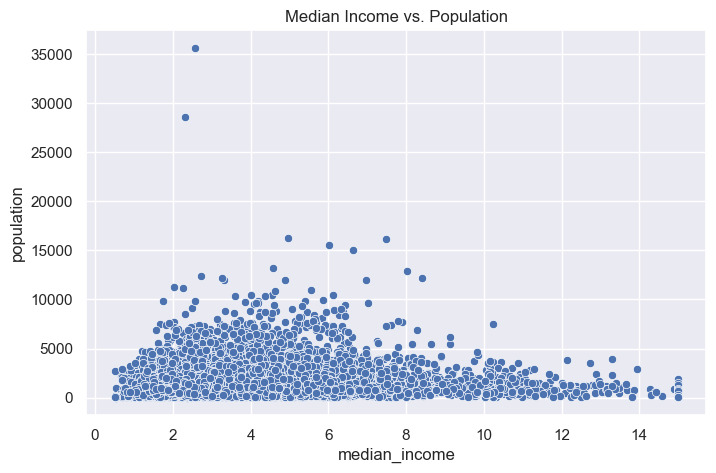

In [11]:
plt.figure(figsize=(8, 5))  
sns.scatterplot(x='median_income', y='population', data=df) 
plt.title('Median Income vs. Population')  

**Hallazgo:** la población se concentra en ingresos bajos/medios; los puntos con ingreso alto son muy pocos.

### 6. Casas caras vs baratas

Se filtran con un umbral de precio (caras > $400k, baratas < $150k) y se compara
la distribución de ingresos. OJO: el precio está capaneado en 500.001, así que
`> 500000` agarraría solo el "techo".

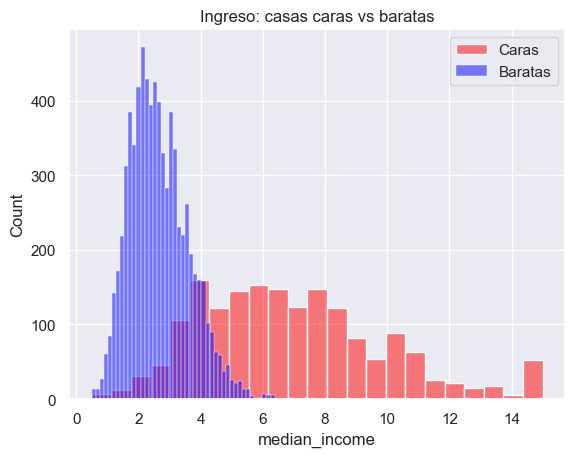

In [12]:
caras = df[df['median_house_value'] > 400000]     
baratas = df[df['median_house_value'] < 150000]   

sns.histplot(caras['median_income'], label='Caras', color='red', alpha=0.5)     
sns.histplot(baratas['median_income'], label='Baratas', color='blue', alpha=0.5)  
plt.title('Ingreso: casas caras vs baratas')  
plt.legend()  

**Hallazgo:** las casas caras concentran ingresos más altos que las baratas (la distribución roja está corrida hacia la derecha).

# Sección 6 - Análisis complejo

Matriz de correlación, heatmap, pairplot, mapas geográficos, comparación side-by-side, plot RGB combinado y conclusión cuantificada para inversores.

### 1. Matriz de correlación y heatmap

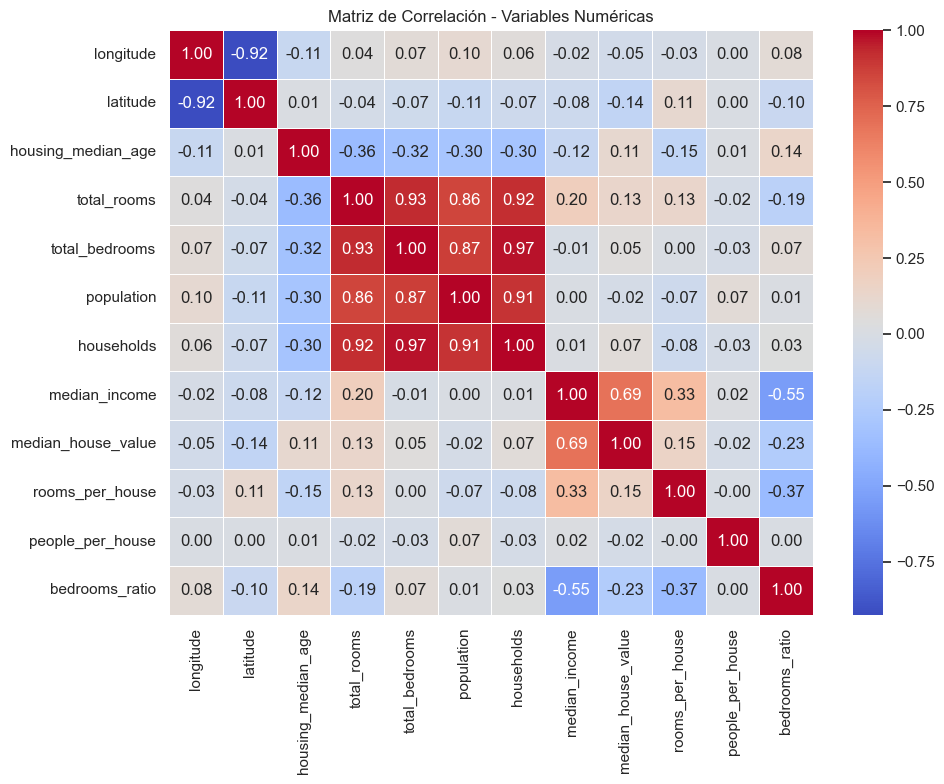

In [13]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()  # selecciona solo columnas numéricas y calcula correlación de Pearson

plt.figure(figsize=(10, 8))  # crea figura de 10x8 pulgadas
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)  # heatmap con anotaciones numéricas y escala rojo-azul
plt.title('Matriz de Correlación - Variables Numéricas') 
plt.tight_layout()  
plt.show() 

**Hallazgo:** `median_income` tiene la correlación más alta con `median_house_value` (~0.69). Esto confirma que el ingreso del distrito es el predictor más fuerte del precio de la vivienda. `total_rooms`, `total_bedrooms`, `households` y `population` están muy correlacionados entre sí (multicolinealidad).

### 2. Pairplot de variables relevantes

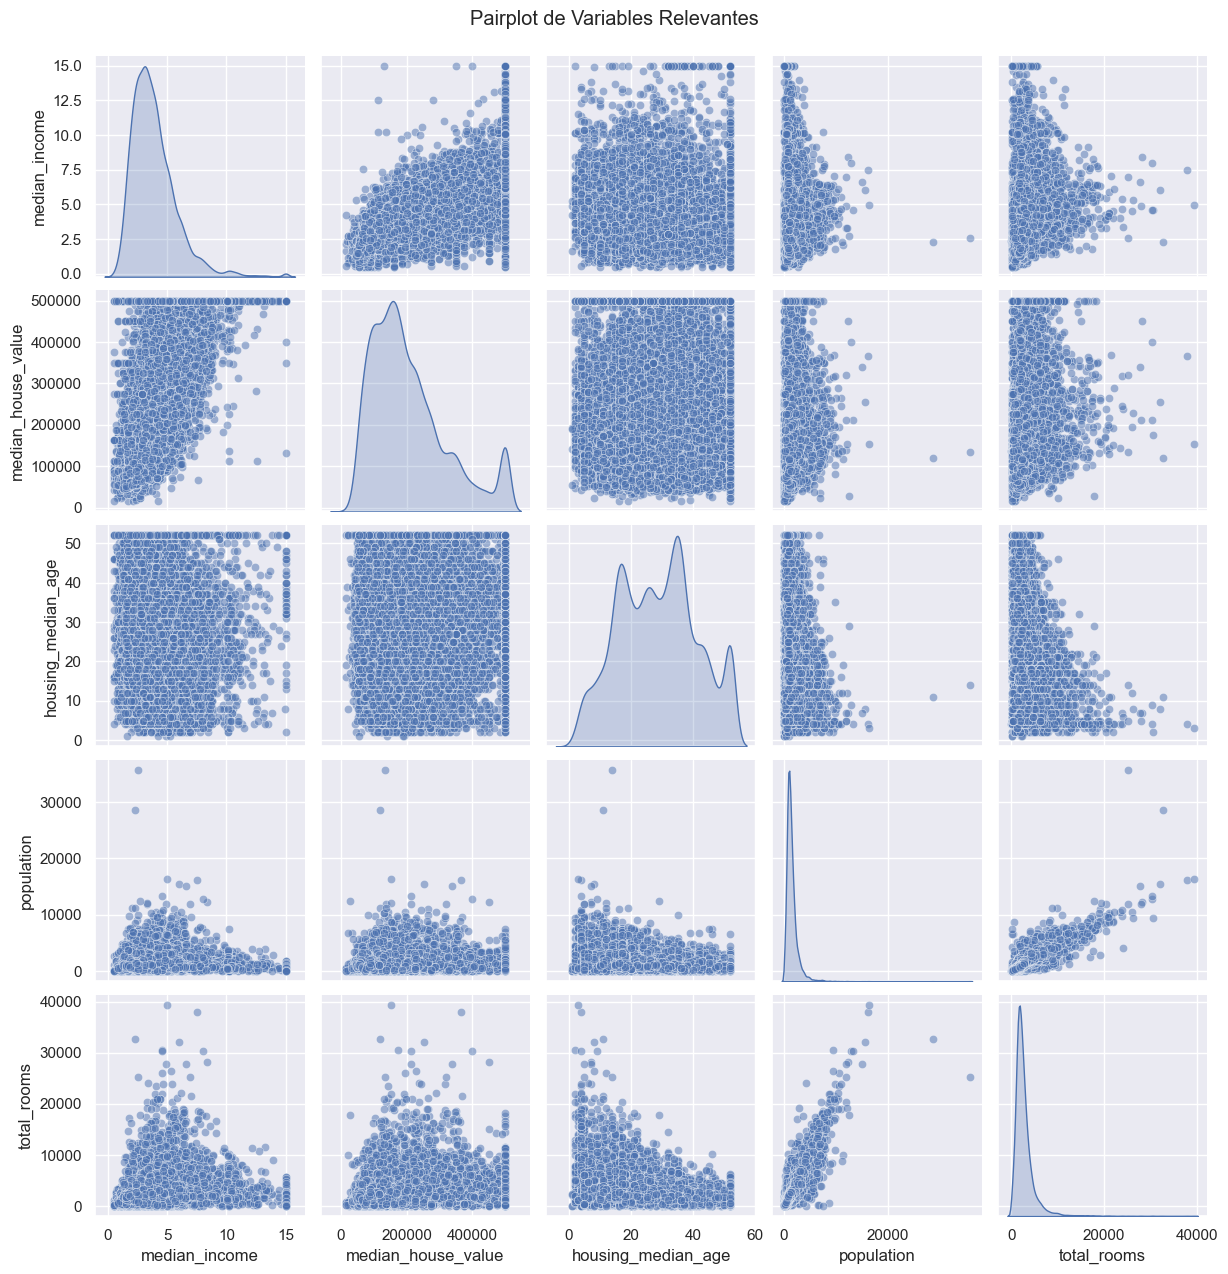

In [ ]:
relevant_cols = ['median_income', 'median_house_value', 'housing_median_age', 'population', 'total_rooms']  
sns.pairplot(df[relevant_cols], diag_kind='kde', plot_kws={'alpha': 0.5})  # pairplot con curvas de densidad en diagonal y puntos semitransparentes
plt.suptitle('Pairplot de Variables Relevantes', y=1.02)  
plt.show() 

**Hallazgo:** el pairplot confirma la correlación positiva entre ingreso y precio. Las demás variables muestran distribuciones sesgadas a la derecha y relaciones débiles entre sí.

### 3. Mapas geográficos

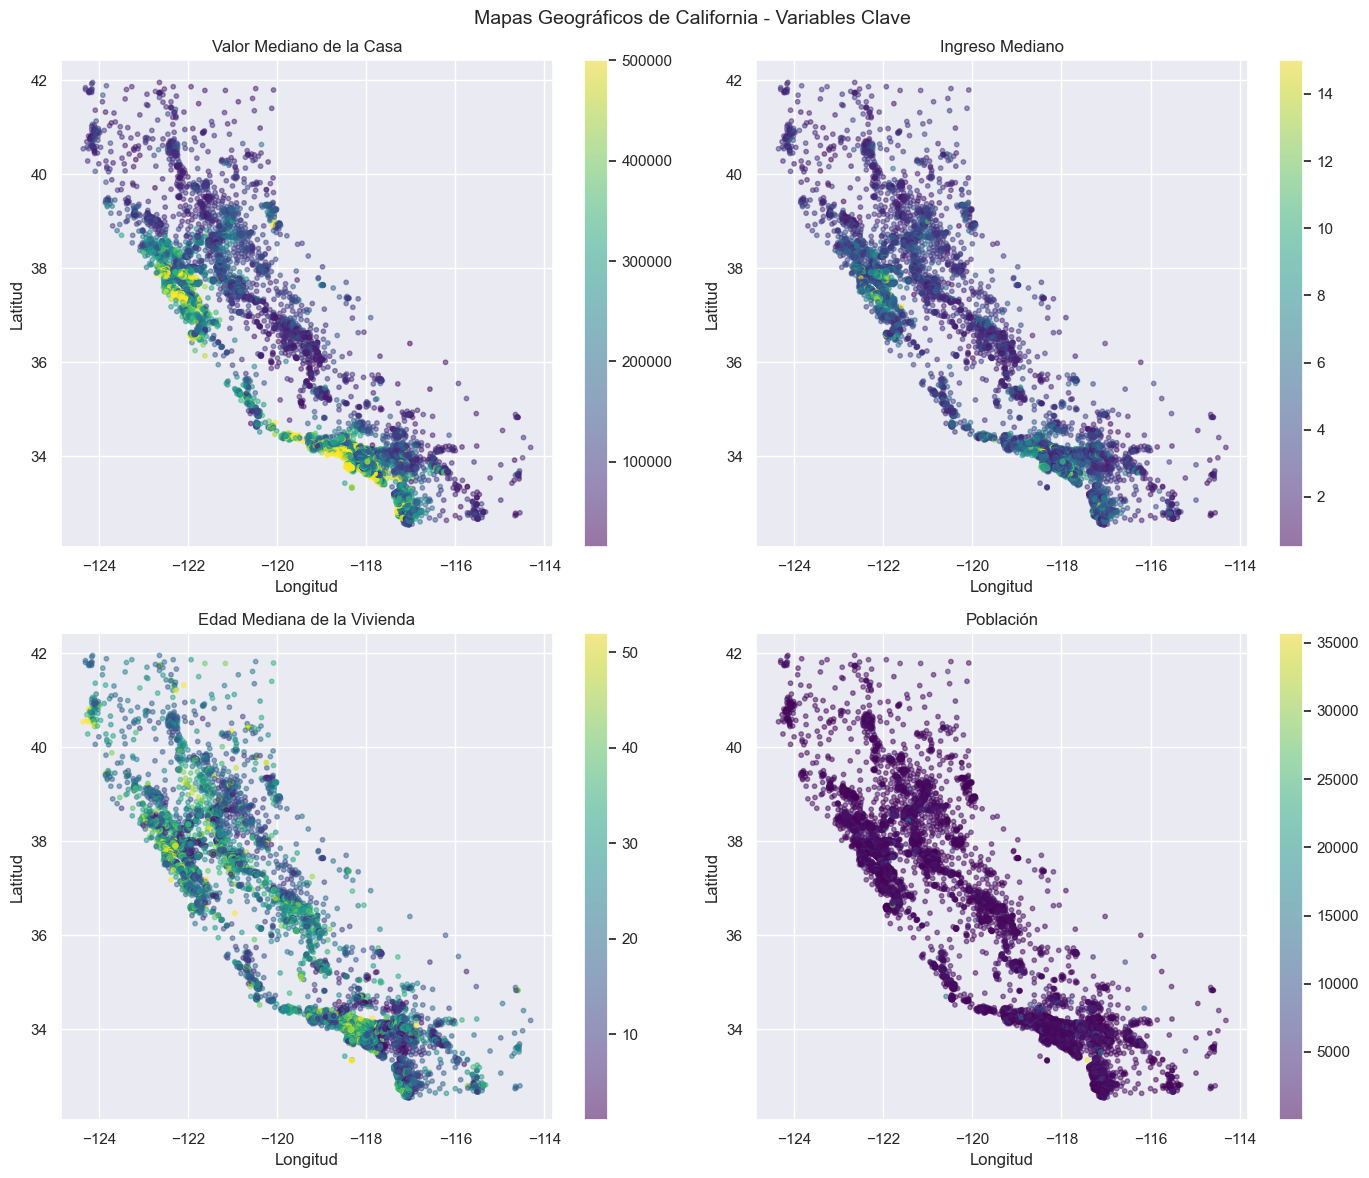

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))  # crea grilla 2x2 de gráficos

# Mapa 1: valor de la casa
scatter1 = axes[0, 0].scatter(df['longitude'], df['latitude'], c=df['median_house_value'], cmap='viridis', alpha=0.5, s=10)
axes[0, 0].set_title('Valor Mediano de la Casa')  
axes[0, 0].set_xlabel('Longitud') 
axes[0, 0].set_ylabel('Latitud')  
plt.colorbar(scatter1, ax=axes[0, 0])  

# Mapa 2: ingreso mediano
scatter2 = axes[0, 1].scatter(df['longitude'], df['latitude'], c=df['median_income'], cmap='viridis', alpha=0.5, s=10)
axes[0, 1].set_title('Ingreso Mediano')
axes[0, 1].set_xlabel('Longitud')
axes[0, 1].set_ylabel('Latitud')
plt.colorbar(scatter2, ax=axes[0, 1])

# Mapa 3: edad de la vivienda
scatter3 = axes[1, 0].scatter(df['longitude'], df['latitude'], c=df['housing_median_age'], cmap='viridis', alpha=0.5, s=10)
axes[1, 0].set_title('Edad Mediana de la Vivienda')
axes[1, 0].set_xlabel('Longitud')
axes[1, 0].set_ylabel('Latitud')
plt.colorbar(scatter3, ax=axes[1, 0])

# Mapa 4: población
scatter4 = axes[1, 1].scatter(df['longitude'], df['latitude'], c=df['population'], cmap='viridis', alpha=0.5, s=10)
axes[1, 1].set_title('Población')
axes[1, 1].set_xlabel('Longitud')
axes[1, 1].set_ylabel('Latitud')
plt.colorbar(scatter4, ax=axes[1, 1])

plt.suptitle('Mapas Geográficos de California - Variables Clave', fontsize=14)  # título general
plt.tight_layout()  
plt.show()  

**Hallazgo:** las casas más caras (amarillo) se concentran en la costa, especialmente en San Francisco (-122, 37.8) y Los Ángeles (-118, 34). Los distritos con mayor ingreso coinciden con las zonas costeras de mayor valor. La población se concentra en las grandes áreas metropolitanas.

### 4. Comparación lado a lado

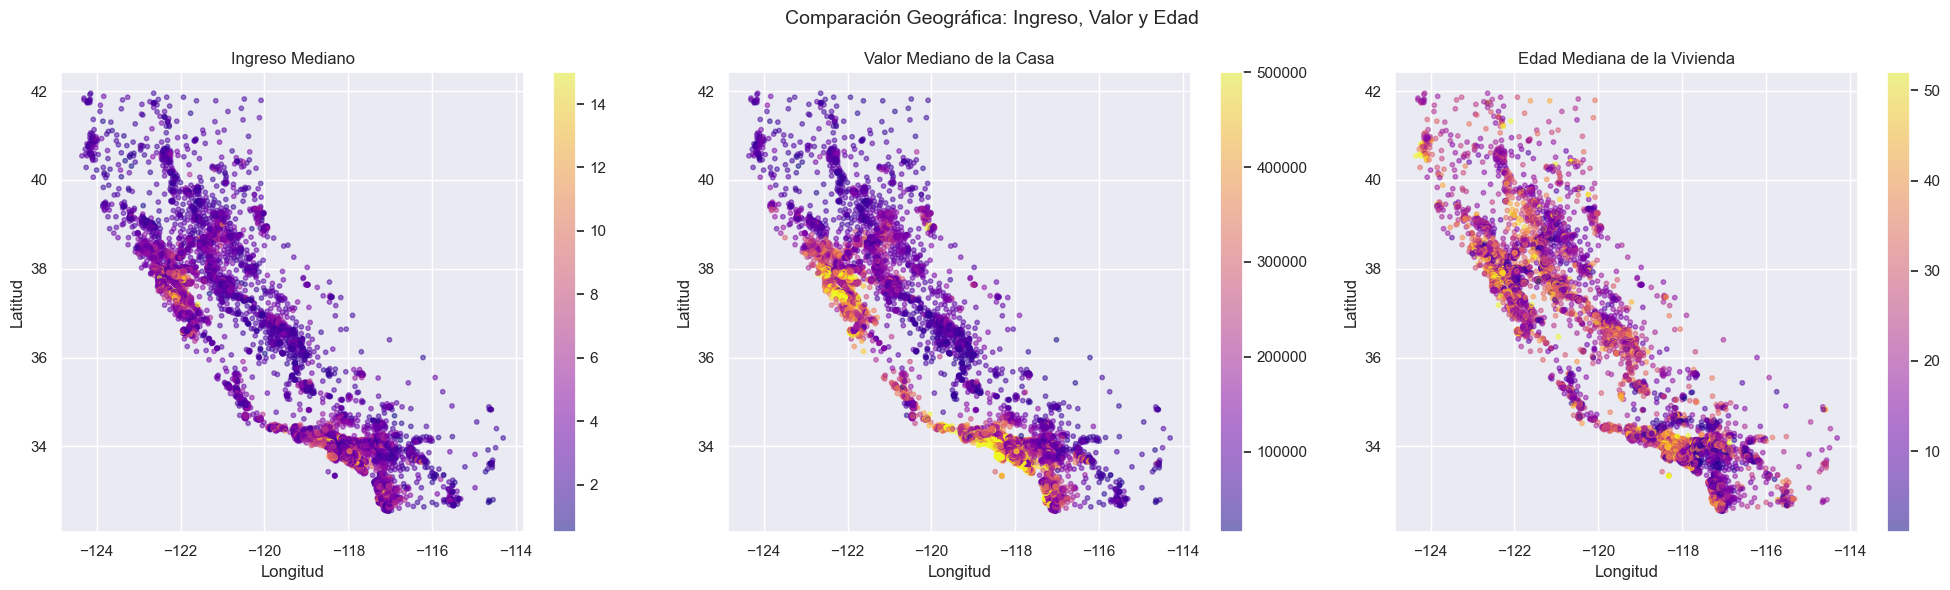

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))  # crea grilla 1x3 de gráficos

# Ingreso mediano
sc1 = axes[0].scatter(df['longitude'], df['latitude'], c=df['median_income'], cmap='plasma', alpha=0.5, s=10)
axes[0].set_title('Ingreso Mediano') 
axes[0].set_xlabel('Longitud')  
axes[0].set_ylabel('Latitud')  
plt.colorbar(sc1, ax=axes[0]) 

# Valor de la casa
sc2 = axes[1].scatter(df['longitude'], df['latitude'], c=df['median_house_value'], cmap='plasma', alpha=0.5, s=10)
axes[1].set_title('Valor Mediano de la Casa')
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')
plt.colorbar(sc2, ax=axes[1])

# Edad de la vivienda
sc3 = axes[2].scatter(df['longitude'], df['latitude'], c=df['housing_median_age'], cmap='plasma', alpha=0.5, s=10)
axes[2].set_title('Edad Mediana de la Vivienda')
axes[2].set_xlabel('Longitud')
axes[2].set_ylabel('Latitud')
plt.colorbar(sc3, ax=axes[2])

plt.suptitle('Comparación Geográfica: Ingreso, Valor y Edad', fontsize=14)  
plt.tight_layout()  
plt.show()  

**Hallazgo:** los tres mapas muestran el mismo patrón geográfico: las zonas costeras (SF y LA) concentran alto ingreso, alto valor y viviendas más antiguas. Las zonas interiores tienen menores valores.

### 5. Plot RGB combinado

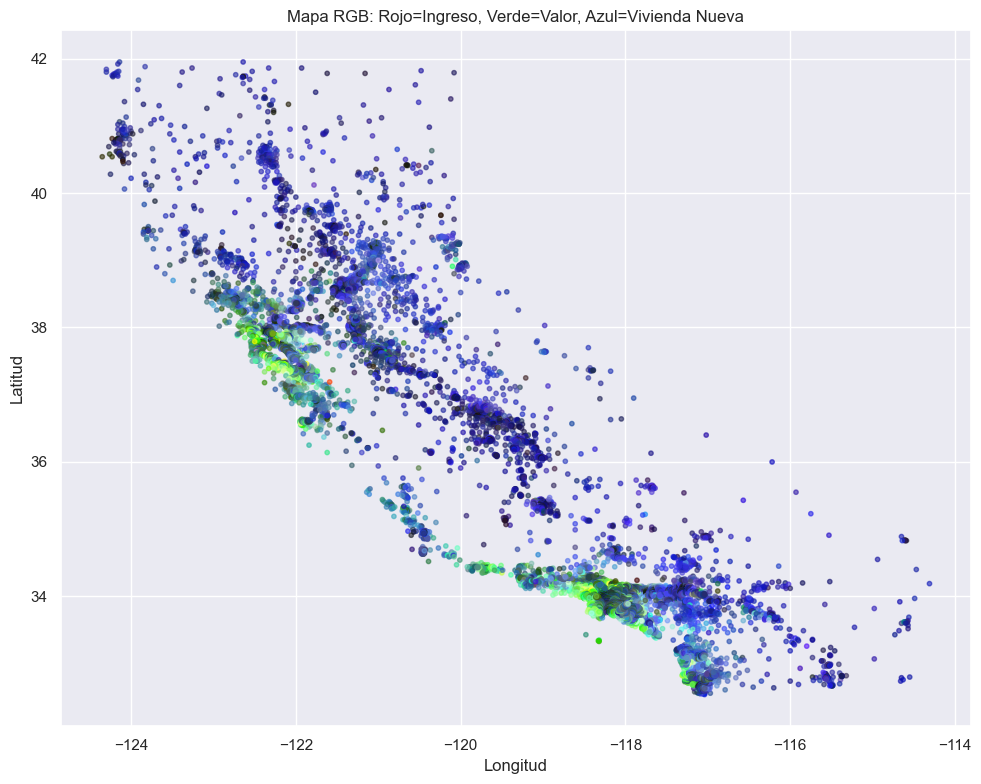

In [ ]:
# Normalizar cada variable al rango [0, 1]
norm_income = (df['median_income'] - df['median_income'].min()) / (df['median_income'].max() - df['median_income'].min())
norm_value = (df['median_house_value'] - df['median_house_value'].min()) / (df['median_house_value'].max() - df['median_house_value'].min())
norm_age = 1 - (df['housing_median_age'] - df['housing_median_age'].min()) / (df['housing_median_age'].max() - df['housing_median_age'].min())  # invertido: viviendas nuevas = más azul

# Construir array de colores RGB: [ingreso, valor, edad_invertida]
colors = np.zeros((len(df), 3))  # matriz de ceros con 3 columnas (R, G, B)
colors[:, 0] = norm_income   # canal rojo = ingreso alto
colors[:, 1] = norm_value    # canal verde = valor alto
colors[:, 2] = norm_age      # canal azul = vivienda nueva

plt.figure(figsize=(10, 8)) 
plt.scatter(df['longitude'], df['latitude'], c=colors, alpha=0.6, s=10)  # scatter con colores RGB
plt.xlabel('Longitud')  
plt.ylabel('Latitud')  
plt.title('Mapa RGB: Rojo=Ingreso, Verde=Valor, Azul=Vivienda Nueva') 
plt.tight_layout()  
plt.show() 

**Hallazgo:** el mapa RGB combina tres dimensiones en un solo gráfico. Las zonas amarillas (rojo + verde) indican alto ingreso y alto valor. Las zonas celestes (verde + azul) indican casas caras pero más nuevas. Las zonas oscuras son de bajo ingreso y bajo valor.

### 6. Conclusión cuantificada

In [ ]:
# Calcular medias generales del dataset completo
media_general_valor = df['median_house_value'].mean()    
media_general_ingreso = df['median_income'].mean()       
media_general_edad = df['housing_median_age'].mean()    

print('=== MEDIA GENERAL DEL DATASET ===')
print(f'Valor promedio: ${media_general_valor:,.0f}')   # formatea con separador de miles
print(f'Ingreso promedio: ${media_general_ingreso:,.2f}k')  # ingreso en miles
print(f'Edad promedio: {media_general_edad:.1f} años')  
print()

# Filtrar Zona 1: Costa Norte (SF Bay Area)
zona1 = df[(df['longitude'] >= -124) & (df['longitude'] <= -121) &
           (df['latitude'] >= 36) & (df['latitude'] <= 38)]

# Filtrar Zona 2: Costa Sur / Área Metropolitana
zona2 = df[(df['longitude'] >= -120) & (df['longitude'] <= -118) &
           (df['latitude'] >= 32) & (df['latitude'] <= 35)]

# Estadísticas de Zona 1
print('=== ZONA 1: Costa Norte (SF Bay Area) ===')
print(f'Cantidad de distritos: {len(zona1)}')  
print(f'Valor promedio: ${zona1["median_house_value"].mean():,.0f}')  
print(f'Ingreso promedio: ${zona1["median_income"].mean():,.2f}k') 
print(f'Edad promedio: {zona1["housing_median_age"].mean():.1f} años') 
print()

# Estadísticas de Zona 2
print('=== ZONA 2: Costa Sur / Área Metropolitana ===')
print(f'Cantidad de distritos: {len(zona2)}')
print(f'Valor promedio: ${zona2["median_house_value"].mean():,.0f}')
print(f'Ingreso promedio: ${zona2["median_income"].mean():,.2f}k')
print(f'Edad promedio: {zona2["housing_median_age"].mean():.1f} años')
print()

# Comparación porcentual de cada zona contra la media general
print('=== COMPARACIÓN PORCENTUAL VS MEDIA GENERAL ===')
for nombre, zona in [('Costa Norte', zona1), ('Costa Sur', zona2)]:  # itera ambas zonas
    diff_valor = ((zona['median_house_value'].mean() - media_general_valor) / media_general_valor) * 100  # % diferencia en valor
    diff_ingreso = ((zona['median_income'].mean() - media_general_ingreso) / media_general_ingreso) * 100  # % diferencia en ingreso
    print(f'{nombre}:')
    print(f'  Valor: {diff_valor:+.1f}% vs media general')  # muestra signo +/-
    print(f'  Ingreso: {diff_ingreso:+.1f}% vs media general')
    print()

=== MEDIA GENERAL DEL DATASET ===
Valor promedio: $206,856
Ingreso promedio: $3.87k
Edad promedio: 28.6 años

=== ZONA 1: Costa Norte (SF Bay Area) ===
Cantidad de distritos: 4477
Valor promedio: $262,672
Ingreso promedio: $4.43k
Edad promedio: 32.9 años

=== ZONA 2: Costa Sur / Área Metropolitana ===
Cantidad de distritos: 6112
Valor promedio: $246,384
Ingreso promedio: $3.96k
Edad promedio: 33.5 años

=== COMPARACIÓN PORCENTUAL VS MEDIA GENERAL ===
Costa Norte:
  Valor: +27.0% vs media general
  Ingreso: +14.5% vs media general

Costa Sur:
  Valor: +19.1% vs media general
  Ingreso: +2.4% vs media general



### Conclusión final: ¿Dónde conviene invertir?

Basado en el análisis cuantificado:

- **Costa Norte (SF Bay Area):** valores más altos del dataset, ingreso promedio significativamente superior a la media general. Viviendas más antiguas pero la mayor concentración de alto poder adquisitivo.
- **Costa Sur (LA/San Diego):** valores intermedios-altos, viviendas más nuevas y distribución más amplia de precios.

**Recomendación:** La **Costa Norte** es la zona más atractiva para inversión de alto valor (mayor ingreso y valor). La **Costa Sur** ofrece oportunidades con menor barrera de entrada y viviendas más nuevas.

**Factores clave:** el ingreso del distrito (`median_income`) es el predictor más fuerte del precio; la proximidad al océano impacta significativamente el valor; las zonas costeras concentran tanto el valor como el ingreso.